# MISO Wind, Solar, and Load Validation

This notebook compares January 2023 MISO actuals with modeled wind, solar, and load using the EIA-860 2022 fleet. The renewable curves show no-loss output and scalar-loss sensitivities; these sensitivities do not change the released scenario products.

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EIA_YEAR = 2022
VALIDATION_YEAR = 2023
WIND_LOSS_PERCENT = 20.0
SOLAR_LOSS_PERCENT = 14.075660705566406
EXPECTED_PLOT_HOURS = 744
LOCAL_TIMEZONE = "America/Chicago"

OUTPUT_DIR = Path("../../notebook_outputs/validation/miso_wind_solar_load_validation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
capacity = pd.read_csv("../../manifests/eia860_2022_operable_capacity_manifest.csv")
capacity = capacity.loc[capacity["BA"].eq("MISO")]
assert len(capacity) == 1, "Expected exactly one MISO capacity row."
installed_wind_mw = float(capacity.iloc[0]["Installed Wind (MW)"])
installed_solar_mw = float(capacity.iloc[0]["Installed Solar (MW)"])

wind_cf = pd.read_csv("../../data/eia860/2022_fleet_validation_cf/MISO_wind_bchrrr_2023.csv", usecols=["time_utc", "wind_cf"])
solar_cf = pd.read_csv("../../data/eia860/2022_fleet_validation_cf/MISO_solar_nsrdb_2023.csv", usecols=["time_utc", "solar_cf"])
wind_actual = pd.read_csv("../../data/renewable_actuals/MISO_wind_2023.csv", usecols=["time_utc", "wind_actual_mw"])
solar_actual = pd.read_csv("../../data/renewable_actuals/MISO_solar_2023.csv", usecols=["time_utc", "solar_actual_mw"])
load_actual = pd.read_csv("../../data/load_actuals/raw/MISO_hourly_load.csv", usecols=["Time_UTC", "Load"]).rename(columns={"Time_UTC": "time_utc", "Load": "load_actual_mw"})
load_modeled = pd.read_csv("../../data/wtk_bchrrr_nsrdb_2007_2023/ba_load/MISO_wtk_bchrrr_nsrdb_2007_2023_load.csv", usecols=["time_utc", "load_mw"]).rename(columns={"load_mw": "load_modeled_mw"})

frames = [wind_cf, solar_cf, wind_actual, solar_actual, load_actual, load_modeled]
for frame in frames:
    frame["time_utc"] = pd.to_datetime(frame["time_utc"], utc=True)
    assert frame["time_utc"].is_unique, "Input timestamps must be unique."

hourly = pd.concat([frame.set_index("time_utc") for frame in frames], axis=1, join="inner").reset_index()
hourly = hourly.loc[hourly["time_utc"].dt.year.eq(VALIDATION_YEAR)].reset_index(drop=True)
assert len(hourly) == 8760 and hourly["time_utc"].is_unique, "Expected 8,760 aligned 2023 hours."
assert hourly.drop(columns="time_utc").notna().all().all(), "Aligned inputs contain missing values."

hourly["wind_modeled_mw_no_loss"] = hourly["wind_cf"] * installed_wind_mw
hourly["wind_modeled_mw_with_loss"] = hourly["wind_modeled_mw_no_loss"] * (1 - WIND_LOSS_PERCENT / 100)
hourly["solar_modeled_mw_no_loss"] = hourly["solar_cf"] * installed_solar_mw
hourly["solar_modeled_mw_with_loss"] = hourly["solar_modeled_mw_no_loss"] * (1 - SOLAR_LOSS_PERCENT / 100)

metric_cases = [
    ("Wind: 0% loss", "wind_actual_mw", "wind_modeled_mw_no_loss"),
    (f"Wind: {WIND_LOSS_PERCENT:g}% loss", "wind_actual_mw", "wind_modeled_mw_with_loss"),
    ("Solar: 0% loss", "solar_actual_mw", "solar_modeled_mw_no_loss"),
    (f"Solar: {SOLAR_LOSS_PERCENT:.1f}% loss", "solar_actual_mw", "solar_modeled_mw_with_loss"),
    ("Load", "load_actual_mw", "load_modeled_mw"),
]
metric_rows = []
for case, actual_column, modeled_column in metric_cases:
    error = hourly[modeled_column] - hourly[actual_column]
    metric_rows.append({"case": case, "mae_mw": error.abs().mean(), "rmse_mw": np.sqrt(np.mean(error**2)), "bias_mw": error.mean(), "n_obs": int(error.notna().sum())})

metrics = pd.DataFrame(metric_rows)
assert len(metrics) == 5
metrics.to_csv(OUTPUT_DIR / "miso_2023_loss_sensitivity_metrics.csv", index=False)
display(metrics.round(2))

,case,mae_mw,rmse_mw,bias_mw,n_obs
0,Wind: 0% loss,2421.16,3107.22,1937.03,8760
1,Wind: 20% loss,1247.76,1599.43,-544.46,8760
2,Solar: 0% loss,245.33,411.95,157.34,8760
3,Solar: 14.1% loss,181.97,310.04,33.20,8760
4,Load,1475.64,1914.05,-320.41,8760


The figure uses local Central time and keeps its labels and styling in the plotting cell for easy editing.

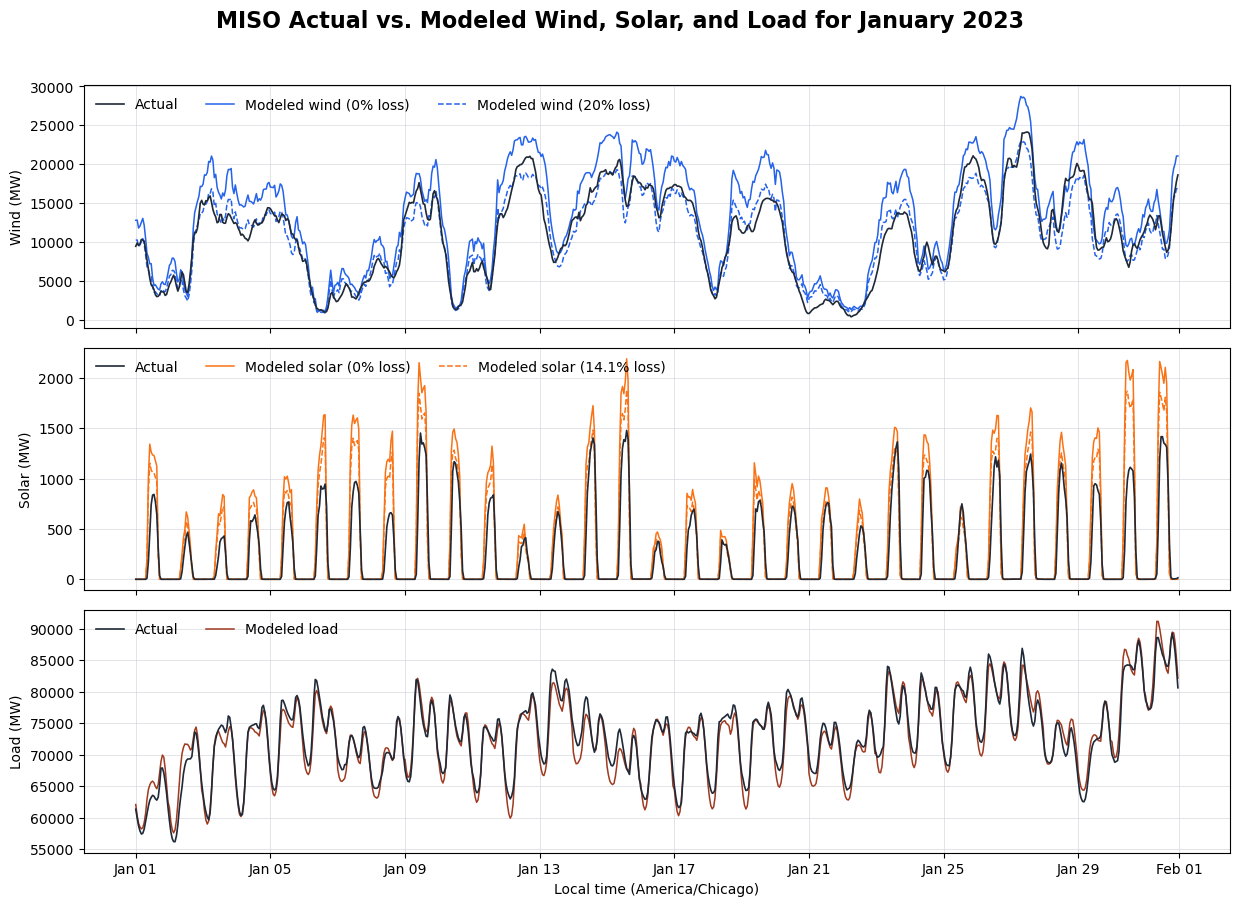

In [3]:
PLOT_TITLE = "MISO Actual vs. Modeled Wind, Solar, and Load for January 2023"
WIND_Y_LABEL = "Wind (MW)"
SOLAR_Y_LABEL = "Solar (MW)"
LOAD_Y_LABEL = "Load (MW)"
X_LABEL = f"Local time ({LOCAL_TIMEZONE})"
ACTUAL_COLOR = "#1f2937"
WIND_COLOR = "#2563eb"
SOLAR_COLOR = "#f97316"
LOAD_COLOR = "#9f3a20"
ACTUAL_LINE_WIDTH = 1.2
MODELED_LINE_WIDTH = 1.1
LOSS_LINE_STYLE = "--"

local = hourly.assign(time_local=hourly["time_utc"].dt.tz_convert(LOCAL_TIMEZONE))
plot_data = local.loc[local["time_local"].dt.year.eq(VALIDATION_YEAR) & local["time_local"].dt.month.eq(1)].copy()
assert len(plot_data) == EXPECTED_PLOT_HOURS, f"Expected {EXPECTED_PLOT_HOURS} January hours."

fig, (ax_wind, ax_solar, ax_load) = plt.subplots(3, 1, figsize=(12.5, 9.2), sharex=True)

ax_wind.plot(plot_data["time_local"], plot_data["wind_actual_mw"], color=ACTUAL_COLOR, linewidth=ACTUAL_LINE_WIDTH, label="Actual", zorder=3)
ax_wind.plot(plot_data["time_local"], plot_data["wind_modeled_mw_no_loss"], color=WIND_COLOR, linewidth=MODELED_LINE_WIDTH, label="Modeled wind (0% loss)")
ax_wind.plot(plot_data["time_local"], plot_data["wind_modeled_mw_with_loss"], color=WIND_COLOR, linewidth=MODELED_LINE_WIDTH, linestyle=LOSS_LINE_STYLE, label=f"Modeled wind ({WIND_LOSS_PERCENT:g}% loss)")
ax_wind.set_ylabel(WIND_Y_LABEL)

ax_solar.plot(plot_data["time_local"], plot_data["solar_actual_mw"], color=ACTUAL_COLOR, linewidth=ACTUAL_LINE_WIDTH, label="Actual", zorder=3)
ax_solar.plot(plot_data["time_local"], plot_data["solar_modeled_mw_no_loss"], color=SOLAR_COLOR, linewidth=MODELED_LINE_WIDTH, label="Modeled solar (0% loss)")
ax_solar.plot(plot_data["time_local"], plot_data["solar_modeled_mw_with_loss"], color=SOLAR_COLOR, linewidth=MODELED_LINE_WIDTH, linestyle=LOSS_LINE_STYLE, label=f"Modeled solar ({SOLAR_LOSS_PERCENT:.1f}% loss)")
ax_solar.set_ylabel(SOLAR_Y_LABEL)

ax_load.plot(plot_data["time_local"], plot_data["load_actual_mw"], color=ACTUAL_COLOR, linewidth=ACTUAL_LINE_WIDTH, label="Actual", zorder=3)
ax_load.plot(plot_data["time_local"], plot_data["load_modeled_mw"], color=LOAD_COLOR, linewidth=MODELED_LINE_WIDTH, label="Modeled load")
ax_load.set_ylabel(LOAD_Y_LABEL)
ax_load.set_xlabel(X_LABEL)

for axis in (ax_wind, ax_solar, ax_load):
    axis.grid(True, color="#d1d5db", linewidth=0.7, alpha=0.65)
    axis.legend(loc="upper left", frameon=False, ncol=3)

ax_load.xaxis.set_major_locator(mdates.DayLocator(bymonthday=range(1, 32, 4), tz=LOCAL_TIMEZONE))
ax_load.xaxis.set_major_formatter(mdates.DateFormatter("%b %d", tz=LOCAL_TIMEZONE))
fig.suptitle(PLOT_TITLE, fontsize=16, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.96))
figure_path = OUTPUT_DIR / "miso_20230101_20230131_loss_sensitivity.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()